<a href="https://colab.research.google.com/github/RamanSambharia/Python-Assignment/blob/main/PAML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ucimlrepo -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from mpl_toolkits.mplot3d import Axes3D

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Fetch dataset directly from UCI repository
dataset = fetch_ucirepo(id=697)

X = dataset.data.features
y = dataset.data.targets

# Combine into one DataFrame for EDA
df = pd.concat([X, y], axis=1)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Dataset Shape: (4424, 37)

First 5 rows:


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
print("Target column name:", y.columns.tolist())
print("\nUnique target values:")
print(df['Target'].value_counts())

# We keep only 'Dropout' and 'Graduate' (drop 'Enrolled' for binary classification)
df = df[df['Target'] != 'Enrolled'].copy()
df['Target'] = df['Target'].map({'Dropout': 1, 'Graduate': 0})

print("\nAfter filtering:")
print(df['Target'].value_counts())
print("New shape:", df.shape)

Target column name: ['Target']

Unique target values:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

After filtering:
Target
0    2209
1    1421
Name: count, dtype: int64
New shape: (3630, 37)


In [4]:
print("=" * 60)
print("TASK 1 — EXPLORATORY DATA ANALYSIS")
print("=" * 60)

print("\nData Types of Each Column:")
print(df.dtypes)

print("\nNumerical Features:")
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numerical_cols)

print("\nCategorical Features:")
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)

TASK 1 — EXPLORATORY DATA ANALYSIS

Data Types of Each Column:
Marital Status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition f

In [5]:
print("Missing Values per Column:")
print(df.isnull().sum())

print("\nTotal Duplicate Rows:", df.duplicated().sum())

# Drop duplicates if any
df = df.drop_duplicates()

print("\nShape after cleaning:", df.shape)
print("\nNo missing values found — dataset is clean.")


Missing Values per Column:
Marital Status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                   

In [7]:
# Check if any encoding is needed
print("Categorical columns requiring encoding:")
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols if cat_cols else "None — all features are already numerical.")

# Target is already encoded (0/1)
print("\nTarget encoding: Dropout=1, Graduate=0")

Categorical columns requiring encoding:
None — all features are already numerical.

Target encoding: Dropout=1, Graduate=0


In [8]:
print("Statistical Summary of Key Features:")
df[['Age at enrollment',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Admission grade',
    'Previous qualification (grade)']].describe().round(2)

Statistical Summary of Key Features:


,Age at enrollment,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),Admission grade,Previous qualification (grade)
count,3630.00,3630.00,3630.00,3630.00,3630.00
mean,23.46,10.53,10.04,127.29,132.92
std,7.83,5.06,5.48,14.61,13.24
min,17.00,0.00,0.00,95.00,95.00
25%,19.00,11.00,10.52,118.00,125.00
50%,20.00,12.34,12.33,126.50,133.10
75%,25.00,13.50,13.50,135.10,140.00
max,70.00,18.88,18.57,190.00,190.00


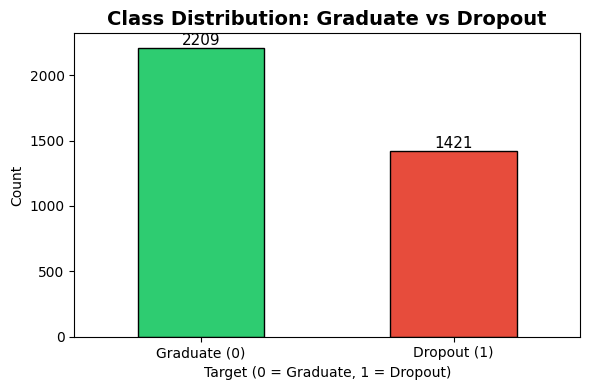

Class distribution saved.


In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#2ecc71', '#e74c3c']
df['Target'].value_counts().plot(kind='bar', color=colors, ax=ax, edgecolor='black')
ax.set_title('Class Distribution: Graduate vs Dropout', fontsize=14, fontweight='bold')
ax.set_xlabel('Target (0 = Graduate, 1 = Dropout)')
ax.set_ylabel('Count')
ax.set_xticklabels(['Graduate (0)', 'Dropout (1)'], rotation=0)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Class distribution saved.")

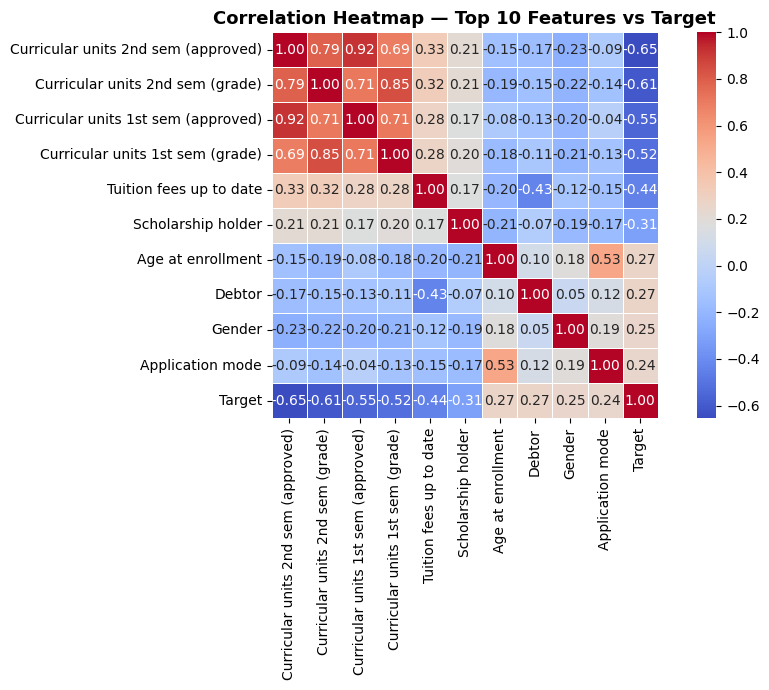

In [10]:
top_features = df.corr()['Target'].abs().sort_values(ascending=False)[1:11].index.tolist()

plt.figure(figsize=(10, 7))
sns.heatmap(df[top_features + ['Target']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Top 10 Features vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

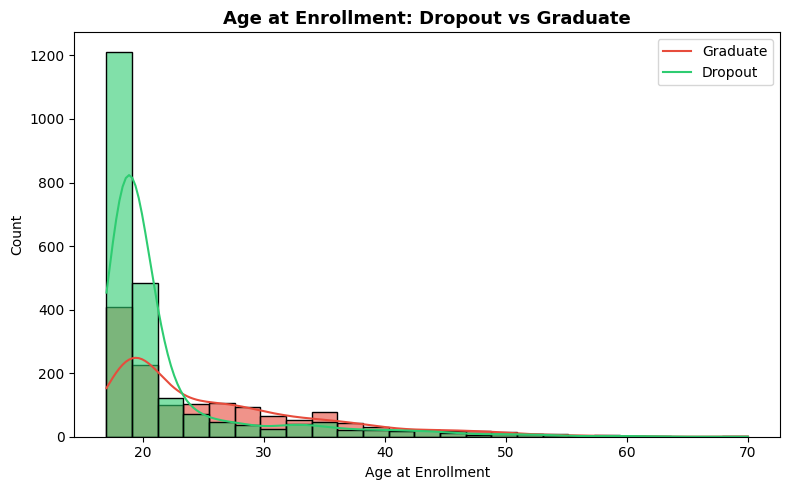

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age at enrollment', hue='Target',
             palette=['#2ecc71', '#e74c3c'],
             kde=True, bins=25, alpha=0.6)
plt.title('Age at Enrollment: Dropout vs Graduate', fontsize=13, fontweight='bold')
plt.xlabel('Age at Enrollment')
plt.ylabel('Count')
plt.legend(labels=['Graduate', 'Dropout'])
plt.tight_layout()
plt.savefig('age_distribution.png', dpi=150)
plt.show()

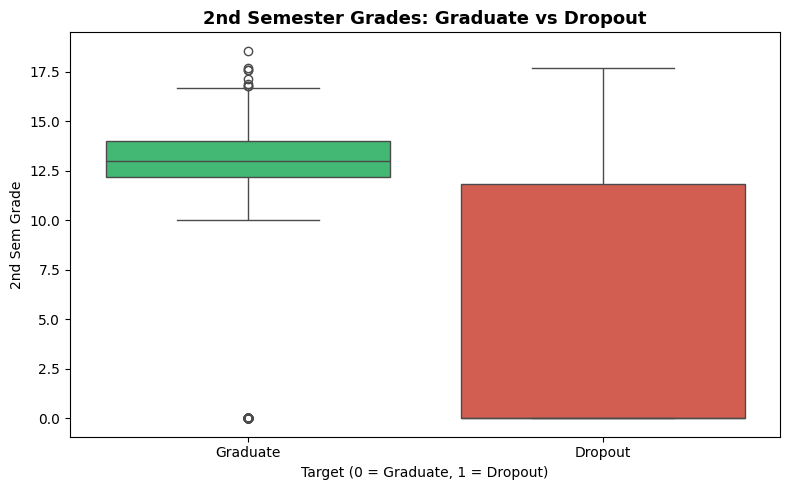

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Target', y='Curricular units 2nd sem (grade)',
            palette=['#2ecc71', '#e74c3c'])
plt.title('2nd Semester Grades: Graduate vs Dropout', fontsize=13, fontweight='bold')
plt.xlabel('Target (0 = Graduate, 1 = Dropout)')
plt.ylabel('2nd Sem Grade')
plt.xticks([0, 1], ['Graduate', 'Dropout'])
plt.tight_layout()
plt.savefig('grades_boxplot.png', dpi=150)
plt.show()

<Figure size 600x400 with 0 Axes>

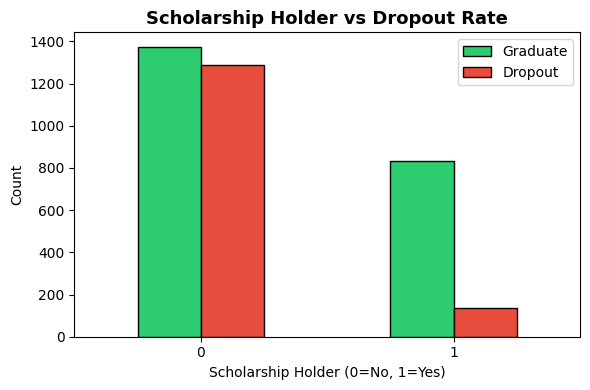

In [16]:
plt.figure(figsize=(6, 4))
scholarship_counts = df.groupby(['Scholarship holder', 'Target']).size().unstack()
scholarship_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'],
                        edgecolor='black', figsize=(6, 4))
plt.title('Scholarship Holder vs Dropout Rate', fontsize=13, fontweight='bold')
plt.xlabel('Scholarship Holder (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Graduate', 'Dropout'])
plt.tight_layout()
plt.savefig('scholarship_vs_dropout.png', dpi=150)
plt.show()

In [17]:
selected_features = df.corr()['Target'].abs().sort_values(ascending=False)[1:16].index.tolist()

print("Selected Features for Modelling:")
print(selected_features)

X = df[selected_features]
y = df['Target']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Selected Features for Modelling:
['Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment', 'Debtor', 'Gender', 'Application mode', 'Curricular units 2nd sem (enrolled)', 'Curricular units 1st sem (enrolled)', 'Admission grade', 'Displaced', 'Curricular units 2nd sem (evaluations)']

Training set: 2904 samples
Test set:     726 samples


In [18]:
print("=" * 60)
print("TASK 2 — SUPPORT VECTOR MACHINE (SVM)")
print("=" * 60)

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm,
                             target_names=['Graduate', 'Dropout']))
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")

TASK 2 — SUPPORT VECTOR MACHINE (SVM)

SVM Classification Report:
              precision    recall  f1-score   support

    Graduate       0.93      0.97      0.95       442
     Dropout       0.95      0.89      0.92       284

    accuracy                           0.94       726
   macro avg       0.94      0.93      0.94       726
weighted avg       0.94      0.94      0.94       726

SVM Accuracy: 0.9394


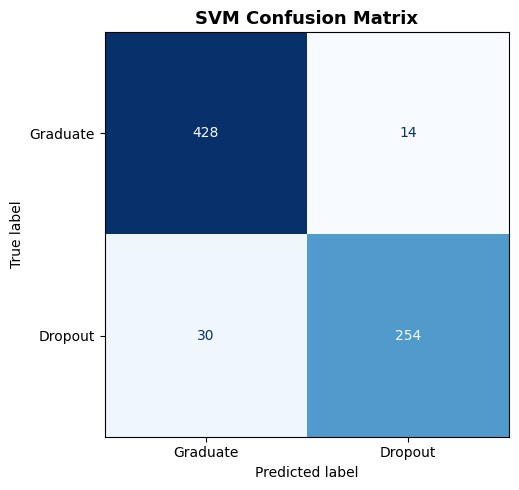

In [19]:
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Graduate', 'Dropout'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('SVM Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=150)
plt.show()

Variance explained by 3 PCA components: 57.40%


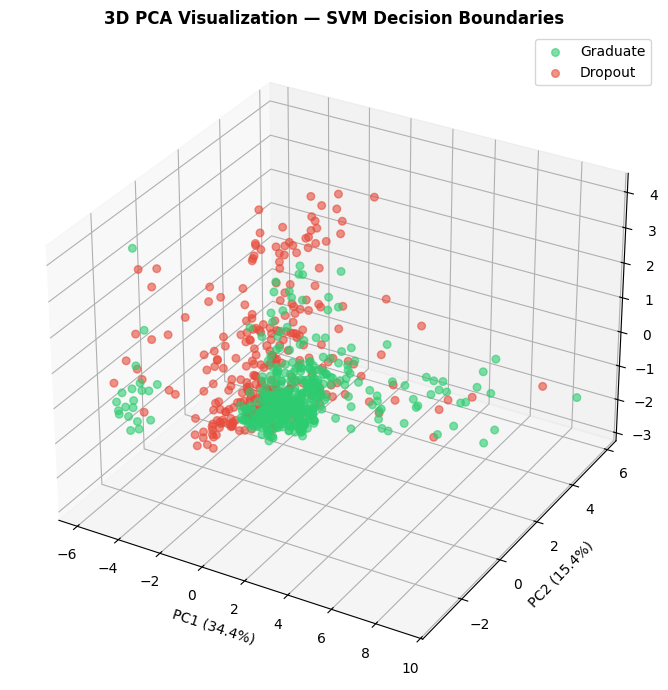

In [20]:
pca = PCA(n_components=3, random_state=42)
X_test_3d = pca.fit_transform(X_test)

explained = pca.explained_variance_ratio_ * 100
print(f"Variance explained by 3 PCA components: {explained.sum():.2f}%")

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

colors_map = {0: '#2ecc71', 1: '#e74c3c'}
labels_map = {0: 'Graduate', 1: 'Dropout'}

for cls in [0, 1]:
    mask = y_test.values == cls
    ax.scatter(X_test_3d[mask, 0],
               X_test_3d[mask, 1],
               X_test_3d[mask, 2],
               c=colors_map[cls],
               label=labels_map[cls],
               alpha=0.6, s=30)

ax.set_title('3D PCA Visualization — SVM Decision Boundaries', fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({explained[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]:.1f}%)')
ax.set_zlabel(f'PC3 ({explained[2]:.1f}%)')
ax.legend()
plt.tight_layout()
plt.savefig('svm_3d_pca.png', dpi=150)
plt.show()

C=0.01   → Accuracy: 0.8747
C=0.1    → Accuracy: 0.9215
C=1      → Accuracy: 0.9394
C=10     → Accuracy: 0.9284
C=100    → Accuracy: 0.9242


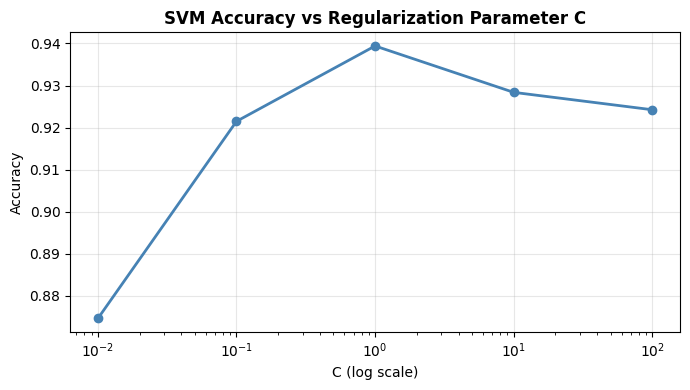

In [21]:
C_values = [0.01, 0.1, 1, 10, 100]
svm_accuracies = []

for c in C_values:
    model = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    svm_accuracies.append(acc)
    print(f"C={c:<6} → Accuracy: {acc:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(C_values, svm_accuracies, marker='o', color='steelblue', linewidth=2)
plt.xscale('log')
plt.title('SVM Accuracy vs Regularization Parameter C', fontsize=12, fontweight='bold')
plt.xlabel('C (log scale)')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('svm_c_tuning.png', dpi=150)
plt.show()

In [22]:
print("=" * 60)
print("TASK 3 — XGBOOST CLASSIFIER")
print("=" * 60)

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1,
                           use_label_encoder=False,
                           eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb,
                             target_names=['Graduate', 'Dropout']))
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")

TASK 3 — XGBOOST CLASSIFIER

XGBoost Classification Report:
              precision    recall  f1-score   support

    Graduate       0.94      0.95      0.94       442
     Dropout       0.91      0.90      0.91       284

    accuracy                           0.93       726
   macro avg       0.92      0.92      0.92       726
weighted avg       0.93      0.93      0.93       726

XGBoost Accuracy: 0.9270


n_estimators=50   → Error: 0.0744
n_estimators=100  → Error: 0.0730
n_estimators=150  → Error: 0.0813
n_estimators=200  → Error: 0.0799
n_estimators=300  → Error: 0.0854
n_estimators=400  → Error: 0.0895
n_estimators=500  → Error: 0.0895


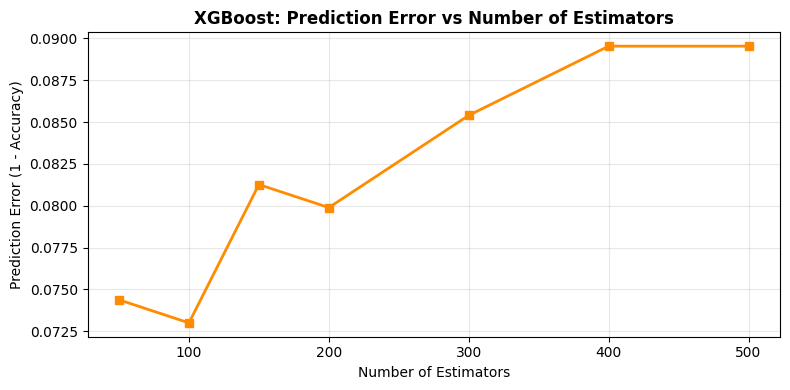


Best n_estimators: 100


In [23]:
estimator_range = [50, 100, 150, 200, 300, 400, 500]
estimator_errors = []

for n in estimator_range:
    model = XGBClassifier(n_estimators=n, learning_rate=0.1,
                          use_label_encoder=False,
                          eval_metric='logloss', random_state=42)
    model.fit(X_train, y_train)
    error = 1 - accuracy_score(y_test, model.predict(X_test))
    estimator_errors.append(error)
    print(f"n_estimators={n:<4} → Error: {error:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(estimator_range, estimator_errors, marker='s',
         color='darkorange', linewidth=2)
plt.title('XGBoost: Prediction Error vs Number of Estimators', fontsize=12, fontweight='bold')
plt.xlabel('Number of Estimators')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('xgb_estimators.png', dpi=150)
plt.show()

best_n = estimator_range[np.argmin(estimator_errors)]
print(f"\nBest n_estimators: {best_n}")


learning_rate=0.001 → Error: 0.3912
learning_rate=0.01  → Error: 0.0882
learning_rate=0.05  → Error: 0.0702
learning_rate=0.1   → Error: 0.0730
learning_rate=0.2   → Error: 0.0826
learning_rate=0.3   → Error: 0.0840
learning_rate=0.5   → Error: 0.1033


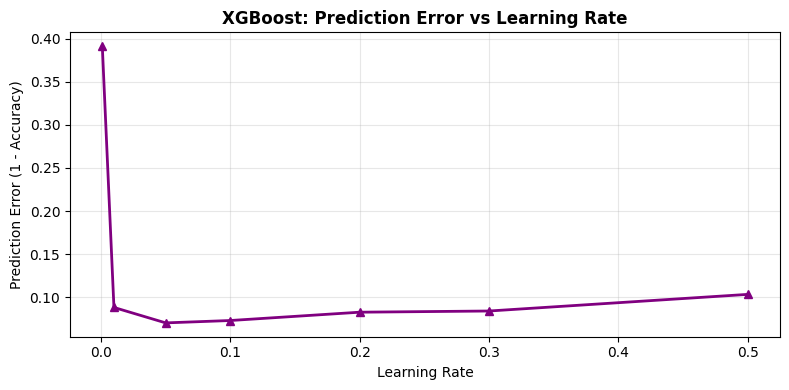


Best learning_rate: 0.05


In [24]:
lr_range = [0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
lr_errors = []

for lr in lr_range:
    model = XGBClassifier(n_estimators=best_n, learning_rate=lr,
                          use_label_encoder=False,
                          eval_metric='logloss', random_state=42)
    model.fit(X_train, y_train)
    error = 1 - accuracy_score(y_test, model.predict(X_test))
    lr_errors.append(error)
    print(f"learning_rate={lr:<5} → Error: {error:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(lr_range, lr_errors, marker='^', color='purple', linewidth=2)
plt.title('XGBoost: Prediction Error vs Learning Rate', fontsize=12, fontweight='bold')
plt.xlabel('Learning Rate')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('xgb_learning_rate.png', dpi=150)
plt.show()

best_lr = lr_range[np.argmin(lr_errors)]
print(f"\nBest learning_rate: {best_lr}")

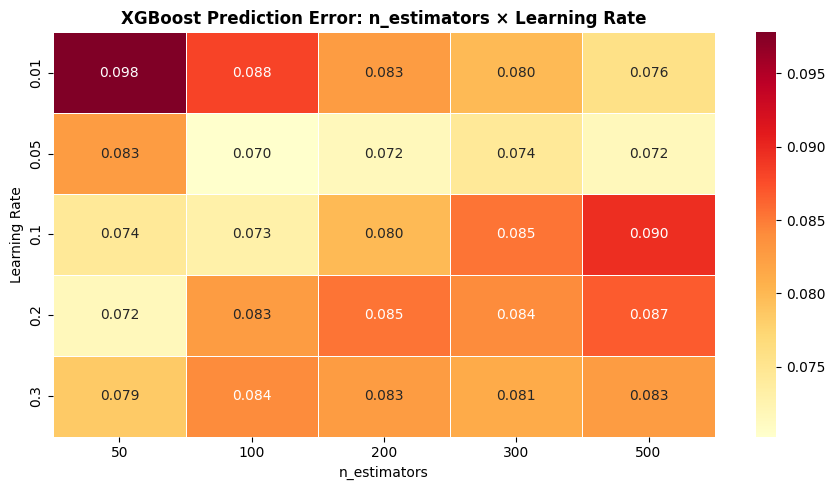

In [25]:
est_vals = [50, 100, 200, 300, 500]
lr_vals  = [0.01, 0.05, 0.1, 0.2, 0.3]

error_matrix = np.zeros((len(lr_vals), len(est_vals)))

for i, lr in enumerate(lr_vals):
    for j, n in enumerate(est_vals):
        model = XGBClassifier(n_estimators=n, learning_rate=lr,
                              use_label_encoder=False,
                              eval_metric='logloss', random_state=42)
        model.fit(X_train, y_train)
        error_matrix[i, j] = 1 - accuracy_score(y_test, model.predict(X_test))

plt.figure(figsize=(9, 5))
sns.heatmap(error_matrix,
            xticklabels=est_vals,
            yticklabels=lr_vals,
            annot=True, fmt='.3f',
            cmap='YlOrRd',
            linewidths=0.5)
plt.title('XGBoost Prediction Error: n_estimators × Learning Rate', fontsize=12, fontweight='bold')
plt.xlabel('n_estimators')
plt.ylabel('Learning Rate')
plt.tight_layout()
plt.savefig('xgb_heatmap.png', dpi=150)
plt.show()

Best XGBoost Model Report:
              precision    recall  f1-score   support

    Graduate       0.93      0.95      0.94       442
     Dropout       0.93      0.89      0.91       284

    accuracy                           0.93       726
   macro avg       0.93      0.92      0.93       726
weighted avg       0.93      0.93      0.93       726

Best XGBoost Accuracy: 0.9298


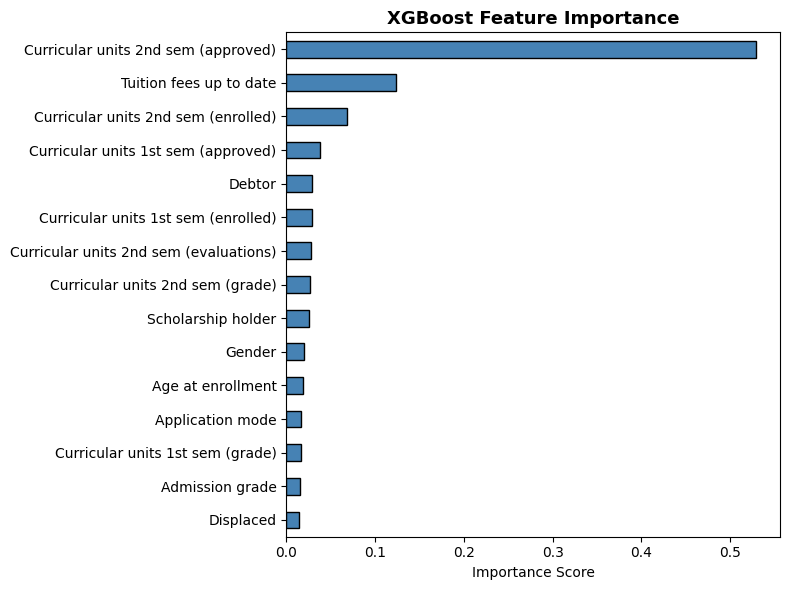

In [26]:
best_xgb = XGBClassifier(n_estimators=best_n, learning_rate=best_lr,
                          use_label_encoder=False,
                          eval_metric='logloss', random_state=42)
best_xgb.fit(X_train, y_train)
y_pred_best = best_xgb.predict(X_test)

print("Best XGBoost Model Report:")
print(classification_report(y_test, y_pred_best,
                             target_names=['Graduate', 'Dropout']))
print(f"Best XGBoost Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")

# Feature importance
importances = pd.Series(best_xgb.feature_importances_, index=selected_features)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('XGBoost Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150)
plt.show()


Final Model Comparison:
                   Model  Accuracy  Error Rate
               SVM (RBF)    0.9394      0.0606
XGBoost (n=100, lr=0.05)    0.9298      0.0702


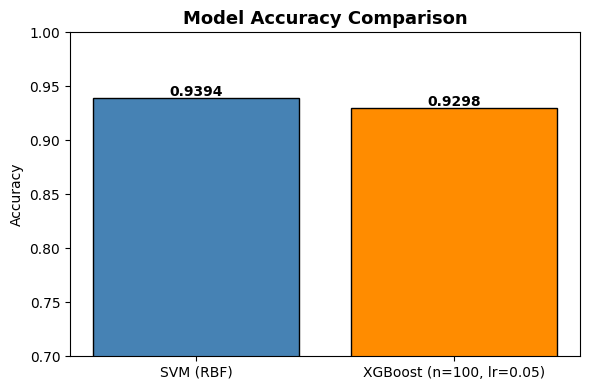


All tasks complete. All plots saved.


In [27]:
svm_acc  = accuracy_score(y_test, y_pred_svm)
xgb_acc  = accuracy_score(y_test, y_pred_best)

summary = pd.DataFrame({
    'Model': ['SVM (RBF)', f'XGBoost (n={best_n}, lr={best_lr})'],
    'Accuracy': [round(svm_acc, 4), round(xgb_acc, 4)],
    'Error Rate': [round(1 - svm_acc, 4), round(1 - xgb_acc, 4)]
})

print("\nFinal Model Comparison:")
print(summary.to_string(index=False))

# Bar chart
plt.figure(figsize=(6, 4))
plt.bar(summary['Model'], summary['Accuracy'],
        color=['steelblue', 'darkorange'], edgecolor='black')
plt.ylim(0.7, 1.0)
plt.title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy')
for i, v in enumerate(summary['Accuracy']):
    plt.text(i, v + 0.002, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

print("\nAll tasks complete. All plots saved.")